# Visualise a dataset of geometries

All atom indices below are 1-based.

In [16]:
# Imports and inputs

import sys
from pathlib import Path

import matplotlib.pyplot as plt
from ase.io import read

repository_path = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "analysis_tools" / "analyse_data" / "visualise_dataset.ipynb").is_file()
)
sys.path[:0] = [str(repository_path)]

from analysis_tools.analyse_data.geometry_coordinates import (
    BondLengthCoordinate,
    BondAngleCoordinate,
    DihedralCoordinate,
)
from analysis_tools.analyse_data.plot_energy_surfaces import (
    plot_energy_mesh_triangulate,
    plot_energy_scatter,
)
from analysis_tools.analyse_data.plot_geometry_features import (
    plot_bond_angle_distribution,
    plot_bond_length_distribution,
    plot_dihedral_distribution,
)
from data_helpers.filtering.filter_ase_atoms import filter_static

XYZ_PATH = (
    '/home/lim_yt/X-MACE-sampling/data/A01_ethene/extended_grid/A01_ethene_grid_static_CASSCF_augmented_manual.xyz'
)

atoms_list = read(XYZ_PATH, index=':')
print(f"Number of geometries: {len(atoms_list)}")

Number of geometries: 7400


In [17]:
# Apply static geometry filter

FILTER_SETTINGS_PATH = Path('../../data_helpers/filtering/null_filter_for_testing.json')
FILTER_BONDS = [(1, 2), (1, 3), (1, 4), (2, 5), (2, 6)]

atoms_list = filter_static(atoms_list, FILTER_SETTINGS_PATH, FILTER_BONDS)
print(f"Number of unfiltered geometries: {len(atoms_list)}")

Number of unfiltered geometries: 7400


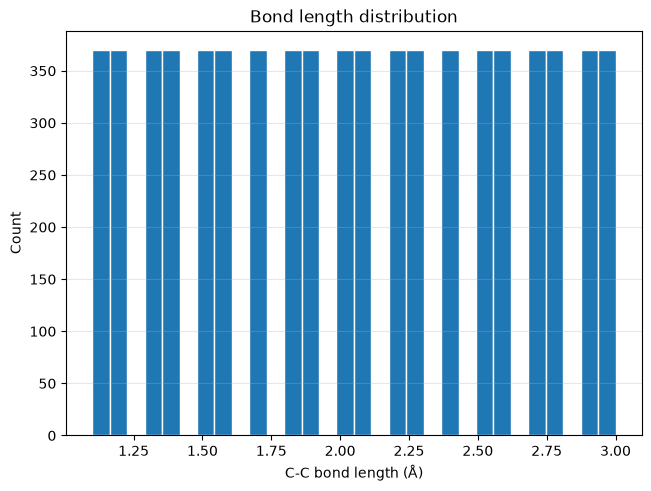

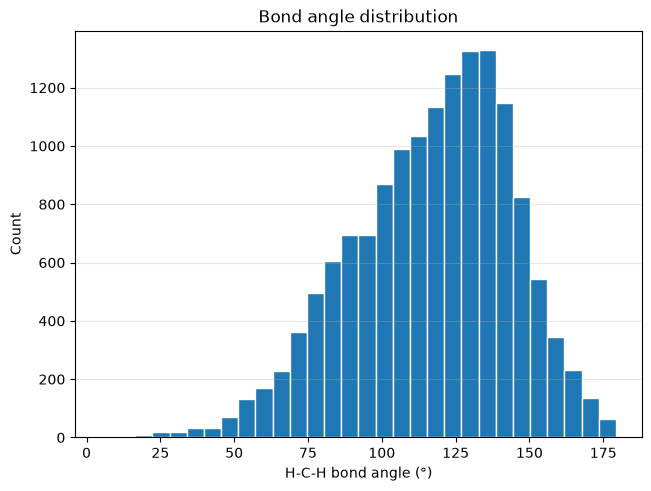

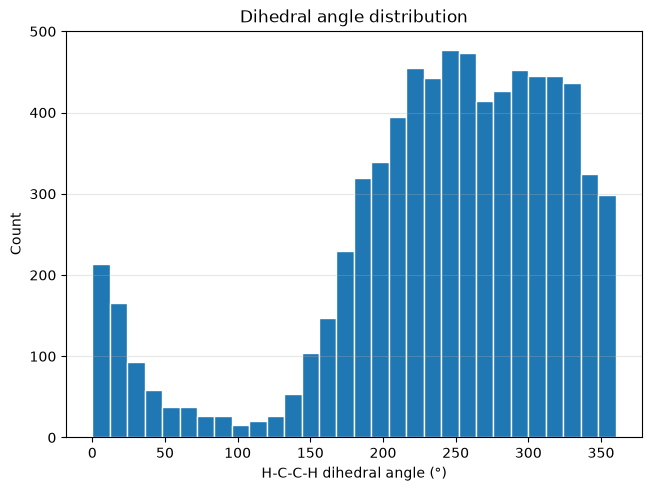

In [18]:
# Plot histograms of bond lengths, angles, dihedrals

# These should point to equivalent bonds/angles/dihedrals that you want to include
# I.e. if BOND_TUPLES = [(1, 3), (1, 4), (2, 5), (2, 6)] each geometry will contribute 4 C-H bond length values to the histogram
BOND_TUPLES = [(1, 2)]  
ANGLE_TUPLES = [(3, 1, 4), (5, 2, 6)]
DIHEDRAL_TUPLES = [(3, 1, 2, 5)]

fig, ax = plot_bond_length_distribution(atoms_list, BOND_TUPLES)
plt.show()

fig, ax = plot_bond_angle_distribution(atoms_list, ANGLE_TUPLES)
plt.show()

fig, ax = plot_dihedral_distribution(atoms_list, DIHEDRAL_TUPLES)
plt.show()

In [ ]:
'''
# FOR AZOBENZENE
# The ring-twist angle (twisting of N-C bond) can be represented using the left and right dihedrals

LEFT_RING_TWIST_ATOMS = (2, 3, 4, 5) # C-C-N=N
RIGHT_RING_TWIST_ATOMS = (4, 5, 6, 7) # N=N-C-C

fig, ax = plot_dihedral_distribution(atoms_list, [LEFT_RING_TWIST_ATOMS, RIGHT_RING_TWIST_ATOMS])
plt.show()
'''

'\n# FOR AZOBENZENE\n# The distribution of ring-twist angle (twisting of N-C bond) can be plotted using the left and right dihedrals\n\nLEFT_RING_TWIST_ATOMS = (2, 3, 4, 5) # C-C-N=N\nRIGHT_RING_TWIST_ATOMS = (4, 5, 6, 7) # N=N-C-C\n\nfig, ax = plot_dihedral_distribution(atoms_list, [LEFT_RING_TWIST_ATOMS, RIGHT_RING_TWIST_ATOMS])\nplt.show()\n'

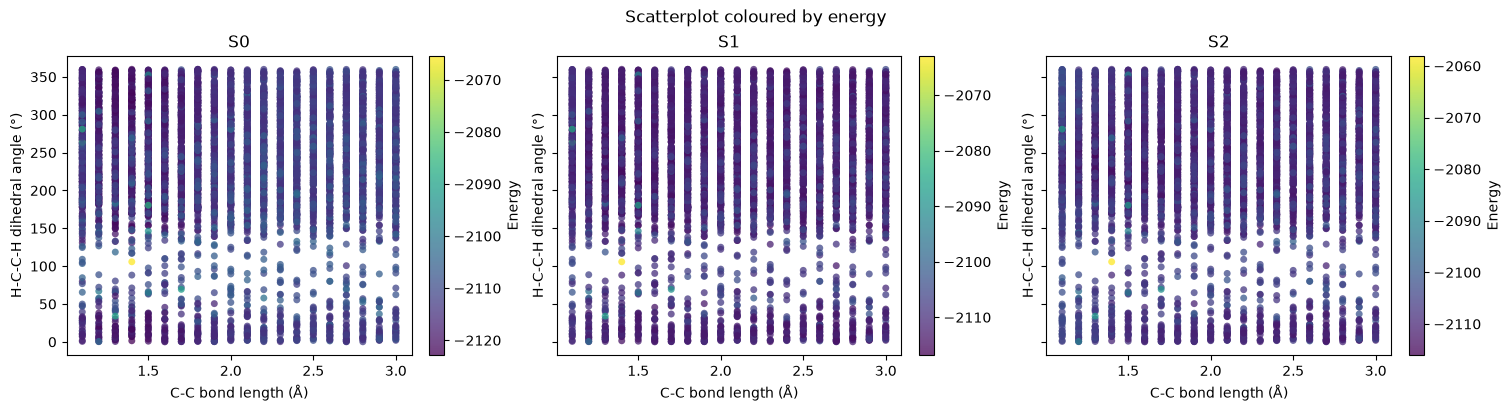

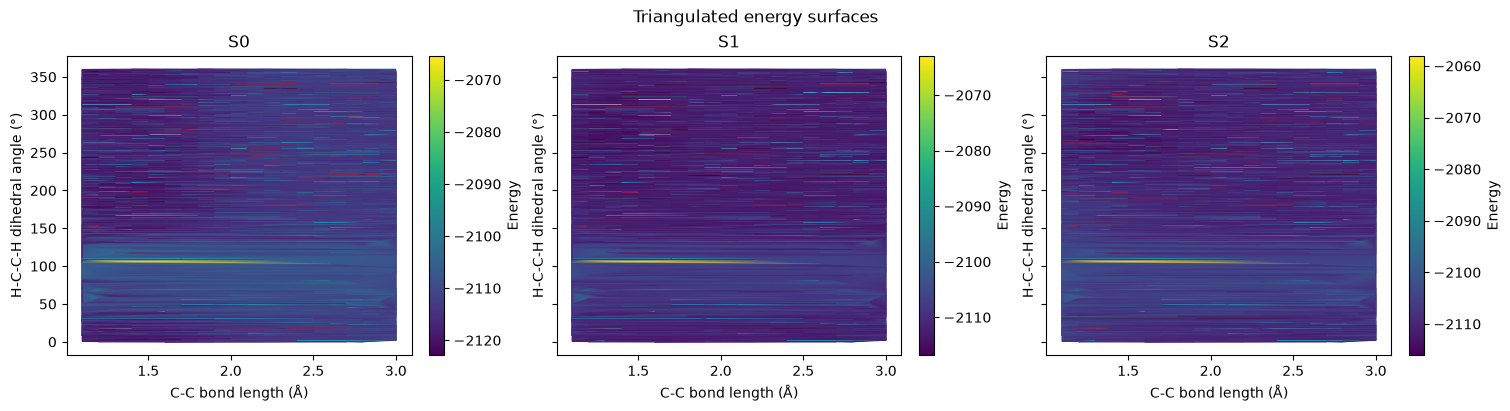

In [20]:
# Plot 2D surfaces with energies encoded as colour

# Choose the x and y coordinates to use
# Options: BondLengthCoordinate((a,b)), BondAngleCoordinate((a,b,c)), DihedralCoordinate((a,b,c,d))
x_coordinate = BondLengthCoordinate((1, 2))
y_coordinate = DihedralCoordinate((3, 1, 2, 5))

fig, ax = plot_energy_scatter(atoms_list, x_coordinate, y_coordinate)
plt.show()

# The triangulated plot fills the region between observed points 
# Averages geometries with the same (x,y) before triangulation
fig, ax = plot_energy_mesh_triangulate(atoms_list, x_coordinate, y_coordinate)
plt.show()